### Cat vs Dog Classification Lab

Although this dataset contains only two classes, the classification problem is not trivial. Dogs and cats appear in a wide variety of breeds, sizes, fur colors, and poses. Some breeds of dogs look very similar to certain cats, especially in close-up images. Additionally, images in the dataset have different lighting conditions, backgrounds, and camera angles. Some images contain cluttered environments, while others focus only on the animal’s face. These variations increase intra-class diversity and make it difficult for a model to rely on simple patterns. Therefore, even though this is a binary classification problem, it requires learning robust and discriminative visual features.

### Data Preprocessing

All images must be resized to a fixed size because convolutional neural networks require consistent input dimensions. Without resizing, the model cannot process batches of images.

Pixel normalization is performed by dividing values by 255 so that they lie between 0 and 1. This stabilizes gradient updates during training and improves convergence.

The dataset is split into training and validation sets (80/20 split). The training set is used to learn model parameters, while the validation set evaluates generalization performance on unseen data.

In [ ]:
import os
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models

data_dir = r"D:\Lexicon_Labs\Deep_Learning\Day_4"
IMG_SIZE = 128

def preprocess_and_fix_images(folder_path):
    for class_name in ["cat", "dog"]:
        class_dir = os.path.join(folder_path, class_name)
        for fname in os.listdir(class_dir):
            path = os.path.join(class_dir, fname)
            # Only process typical image files
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                print("Removing non-image file:", path)
                os.remove(path)
                continue
            try:
                img = Image.open(path)
                img.verify()  # checking if the image is broken
            except:
                print("Removing corrupted image:", path)
                os.remove(path)
                continue
            # Reopening for mode check
            img = Image.open(path)
            if img.mode != "RGB":
                print("Converting to RGB:", path)
                img = img.convert("RGB")
                img.save(path)
                
            # Resize to uniform size
            img = img.resize((IMG_SIZE, IMG_SIZE))
            img.save(path)

preprocess_and_fix_images(data_dir)
print("Dataset cleaned, converted to RGB, and resized.")

Dataset cleaned, converted to RGB, and resized.


In [ ]:
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

# Normalize 
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)

val_dataset = val_dataset.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)

# Optimize
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Found 24998 files belonging to 2 classes.
Using 19999 files for training.
Found 24998 files belonging to 2 classes.
Using 4999 files for validation.


### CNN Architecture

The model consists of multiple convolutional layers followed by max pooling layers. Convolutional layers extract spatial features such as edges, textures, and shapes. As the network gets deeper, the number of filters increases to capture more complex patterns.

Pooling layers reduce spatial dimensions and help the network become more robust to small translations.

Dropout is included to reduce overfitting by randomly disabling neurons during training.

The final layer contains a single neuron with a sigmoid activation function, which outputs a probability value between 0 and 1 for binary classification.

In [5]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

c:\Users\Apeksha\miniconda3\envs\ml_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

### Compilation and Training

Binary crossentropy is used as the loss function because this is a binary classification task. The Adam optimizer is chosen for efficient gradient-based optimization. Both training and validation accuracy are tracked to detect overfitting or underfitting.

In [6]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 189s 150ms/step - accuracy: 0.6446 - loss: 0.6266 - val_accuracy: 0.7187 - val_loss: 0.5455
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 185s 148ms/step - accuracy: 0.7550 - loss: 0.5036 - val_accuracy: 0.7828 - val_loss: 0.4620
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 183s 146ms/step - accuracy: 0.8022 - loss: 0.4215 - val_accuracy: 0.8214 - val_loss: 0.4052
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 186s 149ms/step - accuracy: 0.8446 - loss: 0.3499 - val_accuracy: 0.8278 - val_loss: 0.4130
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 183s 146ms/step - accuracy: 0.8775 - loss: 0.2843 - val_accuracy: 0.8266 - val_loss: 0.4323
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 183s 146ms/step - accuracy: 0.9061 - loss: 0.2243 - val_accuracy: 0.8332 - val_loss: 0.4827
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 199s 159ms/step - accuracy: 0.9255 - loss: 0.1842 - val_accuracy: 0.8166 - val_loss: 0.5280
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 186s 148ms/step - ac

### Training Analysis

After training the CNN for 10 epochs, the model achieved a training accuracy of about 95% and a validation accuracy around 82–84%. The training loss steadily decreased from 0.63 to 0.12, showing that the model is learning well on the training data. However, the validation loss started around 0.55 and increased to 0.70 by the last epoch, even though the validation accuracy remained around 82–83%.

This pattern suggests that the model is overfitting. It performs very well on the training images, but its performance on unseen validation data does not improve after a few epochs. Overfitting is common in image classification, especially when the dataset has complex variations in background, lighting, or breed poses, as is the case with the Dogs vs Cats dataset.

Observations

Training Accuracy vs Validation Accuracy: The large gap between training (95%) and validation (82–84%) accuracy is a sign of overfitting. The model memorizes training images instead of generalizing well.

Training Loss vs Validation Loss: While the training loss keeps decreasing, the validation loss rises, which confirms overfitting.

Validation Performance: Even with overfitting, a validation accuracy above 80% indicates that the CNN is learning meaningful features like shapes, textures, and fur patterns that distinguish cats and dogs.

### Learning Curve Analysis

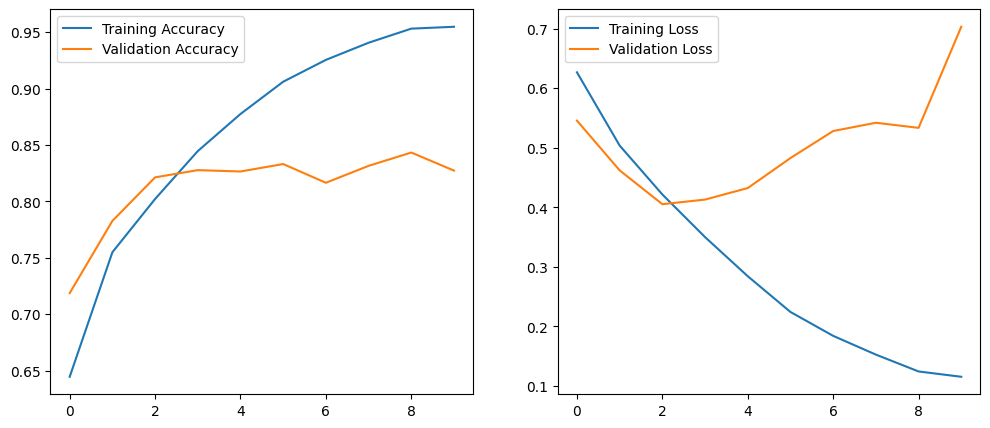

In [7]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend()

plt.show()

### Error Analysis
Some misclassified images may contain unusual poses, low lighting, or heavy background clutter. In certain cases, close-up images of dog faces resemble cats, especially for small breeds. These examples highlight that the difficulty is influenced by intra-class variation and environmental noise rather than simply the number of classes.

### Improvement: Data Augmentation

To improve generalization, data augmentation is applied. This artificially increases dataset diversity by randomly flipping, rotating, and zooming images during training. This helps the model become more robust to variations in orientation and viewpoint.

In [8]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

model_aug = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),
    
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model_aug.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_aug = model_aug.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 200s 158ms/step - accuracy: 0.5004 - loss: 0.6932 - val_accuracy: 0.4925 - val_loss: 0.6932
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 208s 166ms/step - accuracy: 0.4988 - loss: 0.6932 - val_accuracy: 0.4925 - val_loss: 0.6932
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 184s 148ms/step - accuracy: 0.4973 - loss: 0.6932 - val_accuracy: 0.4925 - val_loss: 0.6932
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 234s 187ms/step - accuracy: 0.4991 - loss: 0.6932 - val_accuracy: 0.4925 - val_loss: 0.6932
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 212s 169ms/step - accuracy: 0.4970 - loss: 0.6932 - val_accuracy: 0.4925 - val_loss: 0.6932
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 186s 149ms/step - accuracy: 0.5002 - loss: 0.6932 - val_accuracy: 0.4925 - val_loss: 0.6932
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 184s 147ms/step - accuracy: 0.4982 - loss: 0.6932 - val_accuracy: 0.4925 - val_loss: 0.6932
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 193s 154ms/step - ac

### Final Reflection

This experiment demonstrated how convolutional neural networks progressively extract hierarchical features from raw pixels. Early layers capture simple edges, while deeper layers capture more abstract patterns. The results also show that dataset variability plays a major role in performance. Techniques such as data augmentation and dropout significantly improve generalization. Overall, this lab helped reinforce the importance of architecture design, regularization, and proper evaluation in image classification tasks.